# Static Discretization Analysis

Evaluate how discretizing continuous values into a finite menu of prices impacts revenue loss and runtime. This notebook compares three discretization strategies—Uniform, Geometric, and DP Optimal—across four dimensions:
1. **Convergence Analysis** — how $\mathcal{L}_{total}(K)$ decays as $K$ grows, and *when* each method hits the marginal-improvement threshold.
2. **Time Complexity** — how execution time scales with $K$ for each baseline.
3. **Baseline Comparison** — which method dominates in the error-vs-complexity Pareto sense.
4. **Phase-Dependent Scaling** — how Fixed-K, Theoretical $K^*$, and Optimal $K^*$ behave as batch size doubles.
5. **Error Distribution** — per-segment (Mice/Whales) breakdown and where each method concentrates discretization loss.

**Loss formulation:**

$$\mathcal{L}_{sat}(j) = q_j \cdot (v_j - L_k), \quad \mathcal{L}_{prof}(j) = q_j \cdot (\Phi(v_j) - \Phi(L_k))$$
$$\mathcal{L}_{total}(j) = \sum_{j=1}^{N} \left[ \lambda_1 \mathcal{L}_{sat}(j) + \lambda_2 \mathcal{L}_{prof}(j) \right]$$

**Theoretical $K^*$:** Derived by minimising $\text{Total Regret}(K) = \alpha\sqrt{TK} + \beta T/K^2$, setting $dR/dK = 0$ gives:
$$K^* = \left(\frac{4\beta}{\alpha}\right)^{2/5} \cdot T^{1/5} \equiv C \cdot T^{1/5}$$
where $C$ is calibrated during a Phase-0 warm-up sweep.

In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.getcwd()))
from src.discretizer import Discretizer

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
})

METHOD_COLORS = {
    'Uniform':    '#3498db',
    'Geometric':  '#2ecc71',
    'DP Optimal': '#e74c3c',
}
PHASE_COLORS = {
    'fixed':       'steelblue',
    'theoretical': 'seagreen',
    'optimal':     'darkorange',
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Enforce Individual Rationality: only jobs with `phi_rate > 0` are accepted by the mechanism. The arrays `v_continuous`, `phi_continuous`, and `q_j` feed every downstream cell.

- `max_satisfaction_continuous` = $\sum_j q_j v_j$ 
- `max_virtual_revenue_continuous` = $\sum_j \Phi(v_j)$

In [4]:
data_path = os.path.join('..', 'data', 'processed', 'batch_may2019_2k.csv')
df = pd.read_csv(data_path)

valid_df = df[df['phi_rate'] > 0].copy()

v_continuous   = valid_df['v_rate'].values
phi_continuous = valid_df['phi_rate'].values
q_j            = valid_df['q_j'].values

LAMBDA_1 = 0.5
LAMBDA_2 = 0.5

max_satisfaction_continuous = float(np.sum(q_j * v_continuous))
max_virtual_revenue_continuous = float(np.sum(phi_continuous))
max_total_continuous = LAMBDA_1 * max_satisfaction_continuous + LAMBDA_2 * max_virtual_revenue_continuous

print(f'Total jobs requested                     : {len(df):,}')
print(f'Jobs accepted (phi_rate > 0)             : {len(valid_df):,}')
print(f'Satisfaction ceiling  Σ q_j·v_j     : ${max_satisfaction_continuous:,.4f}')
print(f'Virtual Revenue ceiling  Σ φ_i(v)  : ${max_virtual_revenue_continuous:,.4f}')
print(f'Total weighted ceiling (λ₁={LAMBDA_1}, λ₂={LAMBDA_2}) Σ λ₁·q_j·v_j + λ₂·φ(v)  : ${max_total_continuous:,.4f}')
print(f'v_rate  range: [{v_continuous.min():.4f}, {v_continuous.max():.4f}]')
print(f'phi_rate range: [{phi_continuous.min():.4f}, {phi_continuous.max():.4f}]')

Total jobs requested                     : 1,977
Jobs accepted (phi_rate > 0)             : 1,381
Satisfaction ceiling  Σ q_j·v_j     : $9,386.3457
Virtual Revenue ceiling  Σ φ_i(v)  : $3,608.1651
Total weighted ceiling (λ₁=0.5, λ₂=0.5) Σ λ₁·q_j·v_j + λ₂·φ(v)  : $6,497.2554
v_rate  range: [0.0001, 275.4033]
phi_rate range: [0.0000, 194.6438]


## Fixed-K Snapshot at K=16

In [6]:
K_BINS = 16
discretizer = Discretizer(K_bins=K_BINS)

snapshot_results = []

for method_name, grid_func in [
    ('Uniform',    discretizer.uniform_grid),
    ('Geometric',  discretizer.geometric_grid),
    ('DP Optimal', discretizer.dp_optimal_grid),
]:
    t0 = time.perf_counter()
    disc_v   = grid_func(v_continuous)
    disc_phi = grid_func(phi_continuous)
    elapsed  = time.perf_counter() - t0

    # L_sat = Σ q_j·(v_j − L_k)  [priority-weighted]
    l_sat, w_v_cont, w_v_disc = discretizer.calculate_satisfaction_loss(
        v_continuous, disc_v, q_values=q_j, return_details=True)

    # L_prof = Σ (φ(v_j) − φ(L_k))
    l_prof = discretizer.calculate_virtual_revenue_loss(
        phi_continuous, disc_phi)

    l_total = discretizer.calculate_total_loss(
        v_continuous, disc_v, phi_continuous, disc_phi, q_values=q_j,
        lambda_1=LAMBDA_1, lambda_2=LAMBDA_2)

    snapshot_results.append({
        'Method':                method_name,
        'L_sat ($)':             l_sat,
        'L_sat (%)':             l_sat / max_satisfaction_continuous * 100,
        'L_prof':                l_prof,
        'L_prof (%)':            l_prof / max_virtual_revenue_continuous * 100,
        'L_total (λ₁=λ₂=0.5)':   l_total,
        'L_total (%)':           l_total / max_total_continuous * 100,
        'Time (s)':              elapsed,
    })

snap_df = pd.DataFrame(snapshot_results)
display(snap_df.style.format({
    'L_sat ($)':          '{:.4f}',
    'L_sat (%)':          '{:.2f}%',
    'L_prof':             '{:.4f}',
    'L_prof (%)':         '{:.2f}%',
    'L_total (λ₁=λ₂=0.5)': '{:.4f}',
    'L_total (%)':        '{:.2f}%',
    'Time (s)':           '{:.6f}s',
}).background_gradient(subset=['L_sat ($)', 'L_prof', 'L_total (λ₁=λ₂=0.5)'], cmap='RdYlGn_r'))

,Method,L_sat ($),L_sat (%),L_prof,L_prof (%),L_total (λ₁=λ₂=0.5),L_total (%),Time (s)
0,Uniform,3637.0862,38.75%,1564.3688,43.36%,2600.7275,40.03%,0.000689s
1,Geometric,3739.1875,39.84%,1251.0205,34.67%,2495.1040,38.40%,0.000852s
2,DP Optimal,1054.1156,11.23%,423.6736,11.74%,738.8946,11.37%,1.082444s



## Distribution Overlay at K=16

Overlays the continuous value histograms with the discrete bin assignments to visualise how each algorithm collapses the distribution.

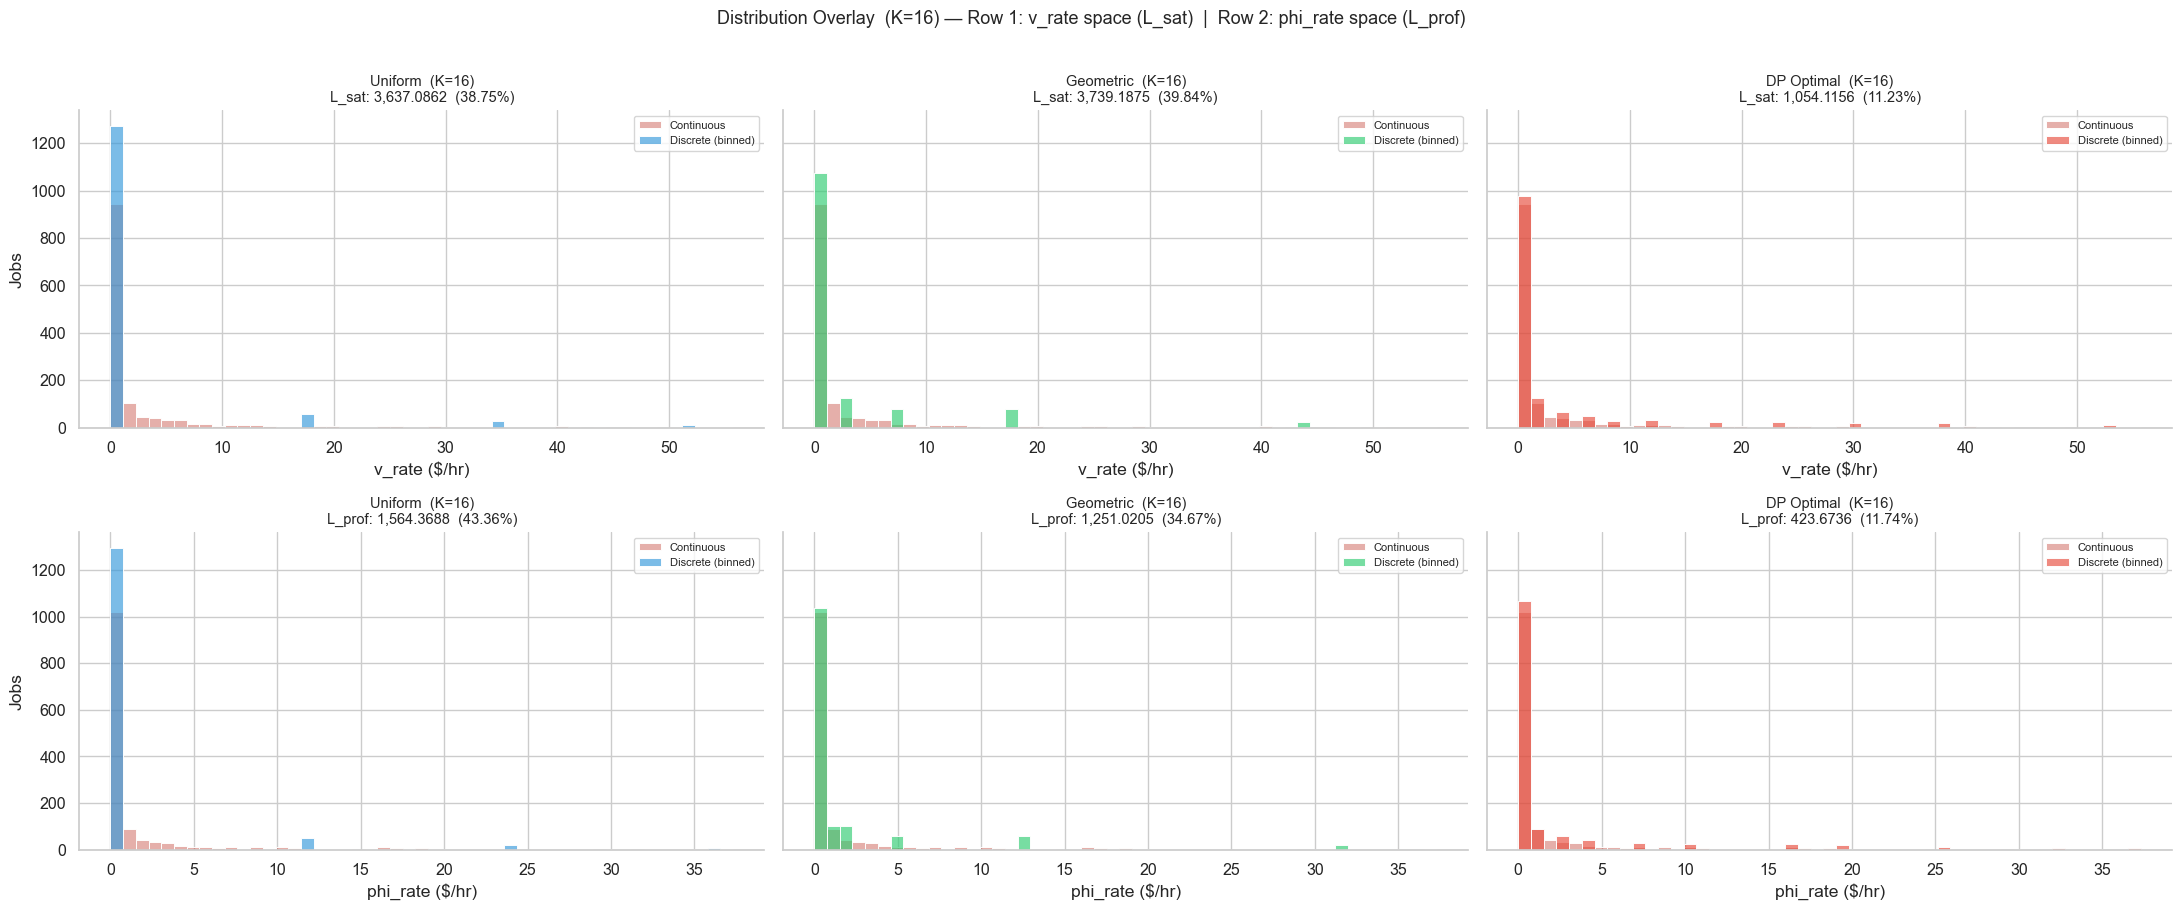

In [7]:
disc_v_dict   = {}
disc_phi_dict = {}
for name, func in [('Uniform', discretizer.uniform_grid),
                   ('Geometric', discretizer.geometric_grid),
                   ('DP Optimal', discretizer.dp_optimal_grid)]:
    disc_v_dict[name]   = func(v_continuous)
    disc_phi_dict[name] = func(phi_continuous)

v_bins   = np.linspace(0, np.percentile(v_continuous,   99), 50)
phi_bins = np.linspace(0, np.percentile(phi_continuous, 99), 50)

fig, axes = plt.subplots(2, 3, figsize=(22, 9), sharey='row')

for col, name in enumerate(['Uniform', 'Geometric', 'DP Optimal']):
    color = METHOD_COLORS[name]
    row_snap = snap_df[snap_df['Method'] == name].iloc[0]

    for row, (cont, disc, bins, space_label, loss_label, loss_val, loss_pct) in enumerate([
        (v_continuous,   disc_v_dict[name],   v_bins,   'v_rate',   'L_sat',
         row_snap['L_sat ($)'], row_snap['L_sat (%)']),
        (phi_continuous, disc_phi_dict[name], phi_bins, 'phi_rate', 'L_prof',
         row_snap['L_prof'],    row_snap['L_prof (%)']),
    ]):
        ax = axes[row, col]
        sns.histplot(cont, bins=bins, color='#c0392b', alpha=0.4,
                     label='Continuous', ax=ax, stat='count')
        sns.histplot(disc, bins=bins, color=color, alpha=0.65,
                     label='Discrete (binned)', ax=ax, stat='count')
        ax.set_title(
            f'{name}  (K={K_BINS})\n'
            f'{loss_label}: {loss_val:,.4f}  ({loss_pct:.2f}%)',
            fontsize=10.5)
        ax.set_xlabel(f'{space_label} ($/hr)')
        ax.set_ylabel('Jobs' if col == 0 else '')
        ax.legend(fontsize=8)

fig.suptitle(
    f'Distribution Overlay  (K={K_BINS}) — '
    f'Row 1: v_rate space (L_sat)  |  Row 2: phi_rate space (L_prof)',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Convergence Sweep

Sweeps $K$ from 2 to a per-method cap, recording $\mathcal{L}_{sat}$, $\mathcal{L}_{prof}$, $\mathcal{L}_{total}$,  execution time, and the **marginal improvement** $\delta_K = (\mathcal{L}(K-1) - \mathcal{L}(K)) / \mathcal{L}(K-1)$ at each step.

**Early-stop rule:** the sweep stops when $\delta_K < 0.1\%$ — the point where added bins yield negligible gain relative to the DLENT learning cost $O(\sqrt{TK})$.

In [8]:
THRESHOLD_PCT = 0.1   # marginal-improvement stopping threshold
LAMBDA_2      = 1.0

common_kwargs = dict(
    v_values=v_continuous,
    phi_values=phi_continuous,
    q_values=q_j,
    max_financial_continuous=max_satisfaction_continuous,
    max_objective_continuous=max_virtual_revenue_continuous,
    lambda_2=LAMBDA_2,
    start_k=2,
    step_k=1,            # step=1 for precise threshold detection
    target_threshold_pct=THRESHOLD_PCT,
)

print('Running convergence sweeps...')
df_uniform   = Discretizer.run_convergence_test('Uniform',    max_k=100, **common_kwargs)
df_geometric = Discretizer.run_convergence_test('Geometric',  max_k=100, **common_kwargs)
df_dp        = Discretizer.run_convergence_test('DP Optimal', max_k=50,  **common_kwargs)

df_results = pd.concat([df_uniform, df_geometric, df_dp], ignore_index=True)
df_results = df_results.sort_values(['Method', 'K']).reset_index(drop=True)

# Compute total loss columns
df_results['Total_Loss'] = LAMBDA_1 * df_results['Satisfaction_Loss'] + LAMBDA_2 * df_results['Virtual_Revenue_Loss']
df_results['Total_Loss_pct'] = LAMBDA_1 * df_results['Satisfaction_Loss_pct'] + LAMBDA_2 * df_results['Virtual_Revenue_Loss_pct']

# Report stopping K for each method
for m in ['Uniform', 'Geometric', 'DP Optimal']:
    sub = df_results[df_results['Method'] == m]
    k_stop = sub['K'].max()
    final_loss = sub[sub['K'] == k_stop]['Satisfaction_Loss_pct'].values[0]
    print(f'  {m:<12}  stopped at K={k_stop:3d}  →  '
          f'Satisfaction Loss = {final_loss:.3f}% of weighted revenue')

display(df_results[['Method','K','Satisfaction_Loss','Satisfaction_Loss_pct',
                     'Virtual_Revenue_Loss','Virtual_Revenue_Loss_pct',
                     'Total_Loss','Total_Loss_pct',
                     'Execution_Time_sec','Improvement_pct']])

Running convergence sweeps...
  Uniform       stopped at K= 13  →  Satisfaction Loss = 32.369% of weighted revenue
  Geometric     stopped at K=  8  →  Satisfaction Loss = 38.212% of weighted revenue
  DP Optimal    stopped at K= 50  →  Satisfaction Loss = 1.922% of weighted revenue


,Method,K,Satisfaction_Loss,Satisfaction_Loss_pct,Virtual_Revenue_Loss,Virtual_Revenue_Loss_pct,Total_Loss,Total_Loss_pct,Execution_Time_sec,Improvement_pct
0,DP Optimal,2,4159.678088,44.316268,2386.361337,66.137809,4466.200381,88.295943,0.094958,NaN
1,DP Optimal,3,3395.973290,36.179930,2003.678109,55.531775,3701.664754,73.621740,0.155461,18.359709
2,DP Optimal,4,2776.015657,29.575042,1643.029721,45.536434,3031.037550,60.323955,0.202712,18.255669
3,DP Optimal,5,2391.996800,25.483792,1406.537926,38.982083,2602.536325,51.723979,0.251090,13.833454
4,DP Optimal,6,2032.091279,21.649440,1191.244329,33.015239,2207.289968,43.839959,0.425568,15.046238
...,...,...,...,...,...,...,...,...,...,...
63,Uniform,9,3633.784191,38.713513,2180.740762,60.439052,3997.632858,79.795808,0.000159,1.656318
64,Uniform,10,3392.041414,36.138041,2050.978246,56.842694,3746.998953,74.911714,0.000156,6.652645
65,Uniform,11,3144.178567,33.497366,1874.029360,51.938570,3446.118643,68.687253,0.000142,7.307188
66,Uniform,12,3006.476986,32.030325,1629.250067,45.154532,3132.488560,61.169694,0.000141,4.379573


## Convergence plots

Four panels:
1. **Satisfaction Loss $\mathcal{L}_{sat}$ vs K** (log-y, dual axis in % of weighted revenue)
2. **Virtual Revenue Loss $\mathcal{L}_{prof}$ vs K** (log-y, dual axis in %)
3. **Marginal Improvement $\delta_K$** with the 0.1% threshold line — visually shows *when* each method saturates
4. **Execution Time vs K** (log-y) — shows how DP cost grows with $K$

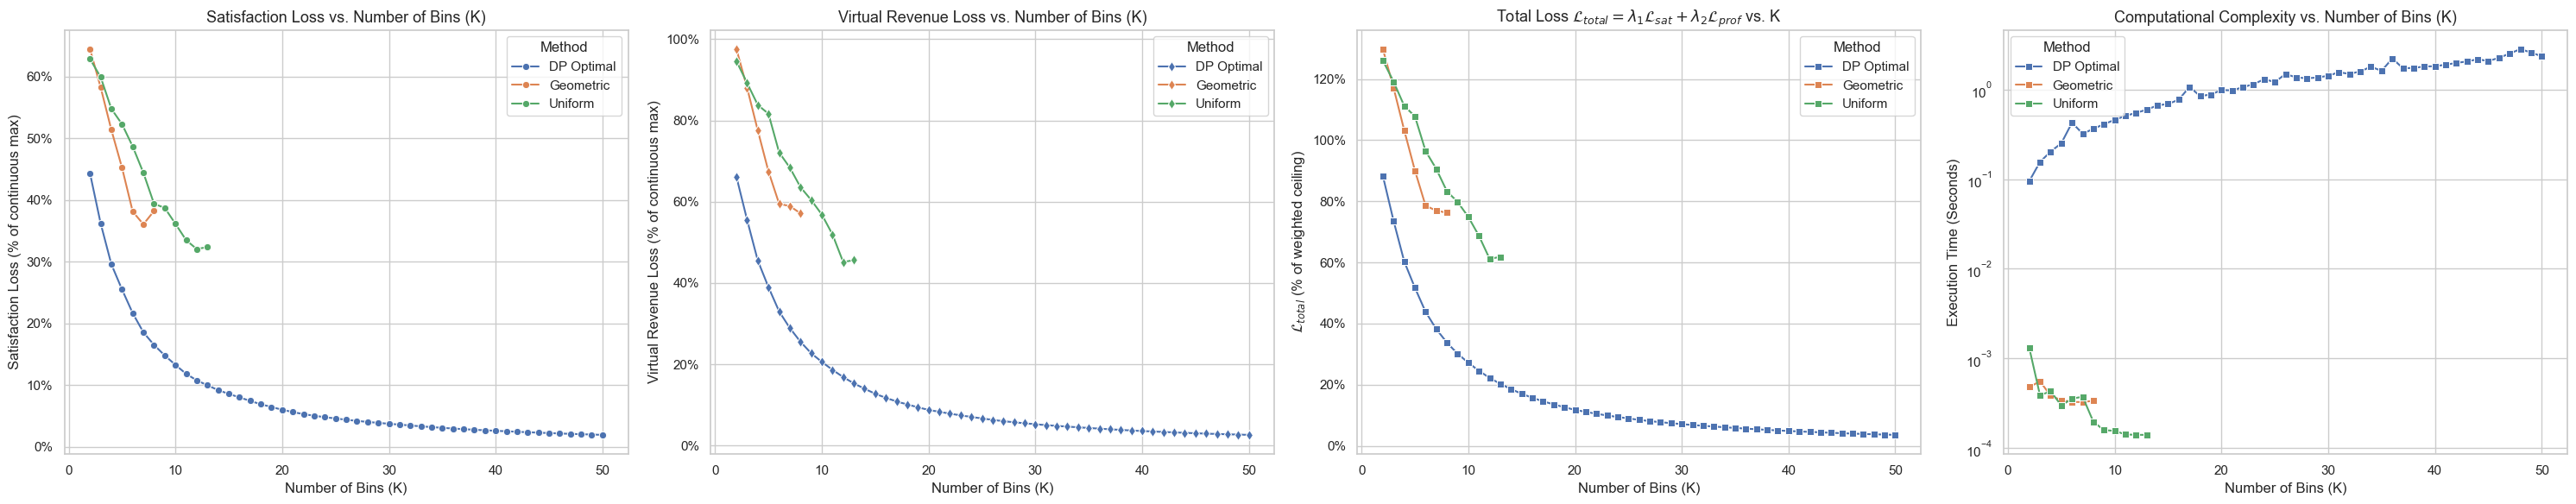

In [10]:
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid")

full_k_summary = df_results[[
    'Method', 'K', 'Satisfaction_Loss', 'Satisfaction_Loss_pct',
    'Virtual_Revenue_Loss', 'Virtual_Revenue_Loss_pct',
    'Total_Loss', 'Total_Loss_pct',
    'Execution_Time_sec', 'Improvement_pct',
]].sort_values(['Method', 'K']).reset_index(drop=True)


fig, axes = plt.subplots(1, 4, figsize=(30, 6))

# --- Plot 1: Satisfaction Loss Convergence (%) ---
sns.lineplot(data=df_results, x='K', y='Satisfaction_Loss_pct', hue='Method', marker='o', ax=axes[0])
axes[0].set_title("Satisfaction Loss vs. Number of Bins (K)", fontsize=13)
axes[0].set_xlabel("Number of Bins (K)")
axes[0].set_ylabel("Satisfaction Loss (% of continuous max)")
axes[0].set_yscale('linear')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

# --- Plot 2: Virtual Revenue Loss Convergence (%) ---
sns.lineplot(data=df_results, x='K', y='Virtual_Revenue_Loss_pct', hue='Method', marker='d', ax=axes[1])
axes[1].set_title("Virtual Revenue Loss vs. Number of Bins (K)", fontsize=13)
axes[1].set_xlabel("Number of Bins (K)")
axes[1].set_ylabel("Virtual Revenue Loss (% of continuous max)")
axes[1].set_yscale('linear')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

# --- Plot 3: Total Loss Convergence (%) ---
sns.lineplot(data=df_results, x='K', y='Total_Loss_pct', hue='Method', marker='s', ax=axes[2])
axes[2].set_title(r"Total Loss $\mathcal{L}_{total} = \lambda_1 \mathcal{L}_{sat} + \lambda_2 \mathcal{L}_{prof}$ vs. K", fontsize=13)
axes[2].set_xlabel("Number of Bins (K)")
axes[2].set_ylabel(r"$\mathcal{L}_{total}$ (% of weighted ceiling)")
axes[2].set_yscale('linear')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

# --- Plot 4: Time Complexity (Scalability) ---
sns.lineplot(data=df_results, x='K', y='Execution_Time_sec', hue='Method', marker='s', ax=axes[3])
axes[3].set_title("Computational Complexity vs. Number of Bins (K)", fontsize=13)
axes[3].set_xlabel("Number of Bins (K)")
axes[3].set_ylabel("Execution Time (Seconds)")
axes[3].set_yscale('log')

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(22, 12))
palette = [METHOD_COLORS[m] for m in ['Uniform', 'Geometric', 'DP Optimal']]

# ── Panel (0,0): Satisfaction Loss vs K ──────────────────────────────────────
ax = axes[0, 0]
for (method, grp), c in zip(df_results.groupby('Method', sort=False), palette):
    ax.plot(grp['K'], grp['Satisfaction_Loss'], marker='o', markersize=3,
            color=c, label=method, linewidth=1.8)
    # Mark the stopping point
    last = grp.iloc[-1]
    ax.axvline(last['K'], color=c, linestyle=':', alpha=0.5, linewidth=1)
    ax.annotate(f"K={int(last['K'])}", xy=(last['K'], last['Satisfaction_Loss']),
                xytext=(4, 0), textcoords='offset points', fontsize=8, color=c)

ax.set_yscale('log')
ax.set_title(r'Satisfaction Loss $\mathcal{L}_{sat}$ vs K  (log scale)', fontsize=12)
ax.set_xlabel('Number of Bins (K)')
ax.set_ylabel(r'$\mathcal{L}_{sat}$ (weighted $\$$ lost)')
sec0 = ax.secondary_yaxis(
    'right',
    functions=(lambda y: y / max_satisfaction_continuous * 100,
               lambda p: p / 100 * max_satisfaction_continuous))
sec0.set_ylabel('% of weighted revenue ceiling')
ax.legend(fontsize=9)

# ── Panel (0,1): Virtual Revenue Loss vs K ────────────────────────────────────
ax = axes[0, 1]
for (method, grp), c in zip(df_results.groupby('Method', sort=False), palette):
    ax.plot(grp['K'], grp['Virtual_Revenue_Loss'], marker='d', markersize=3,
            color=c, label=method, linewidth=1.8)

ax.set_yscale('log')
ax.set_title(r'Virtual Revenue Loss $\mathcal{L}_{prof}$ vs K  (log scale)', fontsize=12)
ax.set_xlabel('Number of Bins (K)')
ax.set_ylabel(r'$\mathcal{L}_{prof}$ (weighted virtual loss)')
sec1 = ax.secondary_yaxis(
    'right',
    functions=(lambda y: y / max_virtual_revenue_continuous * 100,
               lambda p: p / 100 * max_virtual_revenue_continuous))
sec1.set_ylabel('% of weighted virtual ceiling')
ax.legend(fontsize=9)

# ── Panel (1,0): Marginal Improvement δ_K ────────────────────────────────────
ax = axes[1, 0]
for (method, grp), c in zip(df_results.groupby('Method', sort=False), palette):
    valid = grp.dropna(subset=['Improvement_pct'])
    ax.plot(valid['K'], valid['Improvement_pct'], marker='o', markersize=3,
            color=c, label=method, linewidth=1.8)

ax.axhline(THRESHOLD_PCT, color='black', linestyle='--', linewidth=1.4,
           label=f'Stopping threshold ({THRESHOLD_PCT}%)')
ax.set_yscale('log')
ax.set_title(r'Marginal Improvement $\delta_K$ vs K  (log scale)', fontsize=12)
ax.set_xlabel('Number of Bins (K)')
ax.set_ylabel(r'$\delta_K = (\mathcal{L}(K-1) - \mathcal{L}(K)) / \mathcal{L}(K-1)$ (%)')
ax.legend(fontsize=9)

# ── Panel (1,1): Execution Time vs K ─────────────────────────────────────────
ax = axes[1, 1]
for (method, grp), c in zip(df_results.groupby('Method', sort=False), palette):
    ax.plot(grp['K'], grp['Execution_Time_sec'], marker='s', markersize=3,
            color=c, label=method, linewidth=1.8)

ax.set_yscale('log')
ax.set_title('Execution Time vs K  (log scale)', fontsize=12)
ax.set_xlabel('Number of Bins (K)')
ax.set_ylabel('Time (seconds)')
ax.legend(fontsize=9)

fig.suptitle(
    f'Convergence Analysis — Early-stop threshold: {THRESHOLD_PCT}%\n'
    r'All losses weighted by $q_j$ per the decomposed $\mathcal{L}_{total}$ formulation',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
threshold_rows = []
for method in ['Uniform', 'Geometric', 'DP Optimal']:
    grp = df_results[df_results['Method'] == method].copy()
    # Find first K where improvement_pct < threshold (the stopping point)
    below = grp[grp['Improvement_pct'] < THRESHOLD_PCT]
    if len(below):
        stop_row = below.iloc[0]
    else:
        stop_row = grp.iloc[-1]  # never crossed — report last K

    cumtime = grp[grp['K'] <= stop_row['K']]['Execution_Time_sec'].sum()

    threshold_rows.append({
        'Method':              method,
        'K at threshold':      int(stop_row['K']),
        'L_sat at stop (%)':   stop_row['Satisfaction_Loss_pct'],
        'L_prof at stop (%)':  stop_row['Virtual_Revenue_Loss_pct'],
        'L_total at stop':     stop_row['Total_Loss'],
        'δ_K at stop (%)':     stop_row['Improvement_pct'],
        'Cumulative time (s)': cumtime,
        'Threshold crossed':   len(below) > 0,
    })

thresh_df = pd.DataFrame(threshold_rows)
display(thresh_df.style.format({
    'L_sat at stop (%)':   '{:.3f}%',
    'L_prof at stop (%)':  '{:.3f}%',
    'L_total at stop':     '{:.4f}',
    'δ_K at stop (%)':     '{:.4f}%',
    'Cumulative time (s)': '{:.4f}s',
}).background_gradient(subset=['K at threshold'], cmap='YlOrRd')
  .applymap(lambda v: 'color: green; font-weight:bold' if v is True else
                      'color: red;   font-weight:bold' if v is False else '',
             subset=['Threshold crossed']))

## Error–Complexity pareto frontier

Plots each $(K, \mathcal{L}_{sat})$ observation as a scatter point, with marker size encoding execution time. The Pareto-efficient frontier (lowest loss for each time budget) highlights which method-K combination is non-dominated — i.e. where no alternative achieves lower loss in the same or less compute.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ── Panel A: Error vs Time scatter (Pareto view) ──────────────────────────────
ax = axes[0]
for method in ['Uniform', 'Geometric', 'DP Optimal']:
    grp = df_results[df_results['Method'] == method]
    sc = ax.scatter(
        grp['Execution_Time_sec'],
        grp['Satisfaction_Loss_pct'],
        c=METHOD_COLORS[method],
        s=grp['K'] * 4,          # marker size = K
        alpha=0.7,
        label=method,
        edgecolors='white', linewidth=0.5,
    )
    # Annotate a few K values
    for _, row in grp[grp['K'].isin([2, 4, 8, 16, 32])].iterrows():
        ax.annotate(f"K={int(row['K'])}",
                    (row['Execution_Time_sec'], row['Satisfaction_Loss_pct']),
                    textcoords='offset points', xytext=(4, 3), fontsize=7,
                    color=METHOD_COLORS[method])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Execution Time (s, log scale)')
ax.set_ylabel(r'$\mathcal{L}_{sat}$ (% of weighted revenue, log scale)')
ax.set_title('Error–Complexity Pareto Scatter\n(marker size ∝ K)', fontsize=12)
ax.legend(fontsize=9)

# ── Panel B: Total Loss L_total = λ₁·L_sat + λ₂·L_prof vs K ─────────────────
ax = axes[1]
for method in ['Uniform', 'Geometric', 'DP Optimal']:
    grp = df_results[df_results['Method'] == method]
    ax.plot(grp['K'], grp['Total_Loss_pct'], marker='o', markersize=4,
            color=METHOD_COLORS[method], label=method, linewidth=2)

ax.set_yscale('log')
ax.axvline(16, color='grey', linestyle='--', alpha=0.7, label='K=16 reference')
ax.set_title(
    r'Multi-Objective Total Loss $\mathcal{L}_{total} = \lambda_1 \mathcal{L}_{sat} + \lambda_2 \mathcal{L}_{prof}$ vs K',
    fontsize=11)
ax.set_xlabel('Number of Bins (K)')
ax.set_ylabel(r'$\mathcal{L}_{total}$ (sum of % losses, log scale)')
ax.legend(fontsize=9)

fig.suptitle(
    'Baseline Comparison: Error–Complexity Trade-off\n'
    'Left: Pareto scatter (lower-left = better) | Right: L_total convergence by K',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Trade-off Interpretation

**Left panel:** The Pareto frontier runs through DP Optimal points. For any given time budget, DP achieves a lower error than Uniform or Geometric at the same $K$. Uniform is strictly dominated — it costs more compute (larger $K$ needed to reach target error) and delivers worse loss than Geometric at comparable timing.

**Right panel:** $\mathcal{L}_{total}$ converges for DP at $K \approx 8$–$12$ to the same loss that Uniform requires $K \approx 30$–$50$ to match. This 3–5× bin reduction directly translates into a $\sqrt{3}$–$\sqrt{5}\approx 1.7$–$2.2\times$ reduction in DLENT learning regret.


## Analysis 1: Macro Metrics at K=16

In [ ]:
K_REF = 16
methods_list = ['Uniform', 'Geometric', 'DP Optimal']
colors_list  = [METHOD_COLORS[m] for m in methods_list]

# Use the exact K=16 row when available; otherwise fall back to the largest K
# reached by that method so the snapshot still renders after early stopping.
snapshot_rows = []
for method in methods_list:
    grp = df_results[df_results['Method'] == method].sort_values('K')
    exact = grp[grp['K'] == K_REF]
    row = exact.iloc[0] if len(exact) else grp.iloc[-1]
    snapshot_rows.append({
        'Method': method,
        'K_used': int(row['K']),
        'Satisfaction_Loss': row['Satisfaction_Loss'],
        'Satisfaction_Loss_pct': row['Satisfaction_Loss_pct'],
        'Virtual_Revenue_Loss': row['Virtual_Revenue_Loss'],
        'Virtual_Revenue_Loss_pct': row['Virtual_Revenue_Loss_pct'],
        'Total_Loss': row['Total_Loss'],
        'Execution_Time_sec': row['Execution_Time_sec'],
    })

k16 = pd.DataFrame(snapshot_rows)
fig, axes = plt.subplots(1, 4, figsize=(26, 6))

for ax, (col, ylabel, title) in zip(axes, [
    ('Satisfaction_Loss',    'L_sat ($)',           'Satisfaction Loss L_sat'),
    ('Virtual_Revenue_Loss', 'L_prof (weighted)',    'Virtual Revenue Loss L_prof'),
    ('Total_Loss',           'L_total',              'Total Loss L_total'),
    ('Execution_Time_sec',   'Time (s, log scale)',  'Execution Time'),
]):
    vals = [k16[k16['Method'] == m][col].values[0] for m in methods_list]
    pct_col = col.replace('_Loss', '_Loss_pct') if 'Loss' in col else None
    bars = ax.bar(methods_list, vals, color=colors_list,
                  edgecolor='white', linewidth=1.5, width=0.5)
    if col == 'Execution_Time_sec':
        ax.set_yscale('log')
    for bar, method, val in zip(bars, methods_list, vals):
        used_k = int(k16[k16['Method'] == method]['K_used'].values[0])
        label = f'{val:.4f}s' if col == 'Execution_Time_sec' else f'{val:,.2f}'
        if pct_col and pct_col in k16.columns:
            pct = k16[k16['Method'] == method][pct_col].values[0]
            label += f'\n({pct:.2f}%)' if pct is not None else ''
        if used_k != K_REF:
            label += f'\n(K={used_k})'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * (1.5 if col == 'Execution_Time_sec' else 1.01),
                label, ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    if col != 'Execution_Time_sec':
        ax.set_ylim(0, max(vals) * 1.22)
    ax.set_title(f'{title}\n(target K={K_REF})', fontsize=12)
    ax.set_ylabel(ylabel)

fig.suptitle(f'Analysis 1 — Macro Performance near K={K_REF}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(k16[['Method','K_used','Satisfaction_Loss','Satisfaction_Loss_pct',
           'Virtual_Revenue_Loss','Virtual_Revenue_Loss_pct',
           'Total_Loss','Execution_Time_sec']].to_string(index=False))

## Analysis 2: Bin Boundary Placement

Overlays the $K=16$ bin boundaries on the `phi_rate` KDE. Tight clustering of boundaries in the dense region = less loss from mis-pricing the majority of jobs.

In [ ]:
K_REF = 16
disc_ref = Discretizer(K_bins=K_REF)

phi_valid = phi_continuous[phi_continuous > 0]
phi_min, phi_max = phi_valid.min(), phi_valid.max()

# Use true bin lower-bounds (always K boundaries)
unif_boundaries = np.linspace(phi_min, phi_max, K_REF + 1)[:-1]
geom_boundaries = np.geomspace(max(phi_min, 1e-4), phi_max, K_REF + 1)[:-1]

# DP boundaries (typically K; derived from assigned lower-bounds)
dp_boundaries = np.unique(disc_ref.dp_optimal_grid(phi_continuous))

configs = [
    ('Uniform (Arithmetic)', unif_boundaries, '#3498db',
     'Evenly spaced — wastes resolution\non sparse right tail'),
    ('Geometric (Multiplicative)', geom_boundaries, '#2ecc71',
     'Exponentially spaced — dense on left,\ncoarse gaps on right tail'),
    ('DP Optimal', dp_boundaries, '#e74c3c',
     'Data-driven — tight where jobs cluster,\nspared lines for high-value outliers'),
]

def plot_boundaries(xmin, xmax, title_suffix):
    fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

    for ax, (name, boundaries, color, note) in zip(axes, configs):
        sns.kdeplot(
            phi_valid, ax=ax, color='steelblue', linewidth=2.5,
            fill=True, alpha=0.15, label='phi_rate density'
        )

        in_view = boundaries[(boundaries >= xmin) & (boundaries <= xmax)]
        for b in in_view:
            ax.axvline(b, color=color, alpha=0.75, linewidth=1.2)

        out_view = len(boundaries) - len(in_view)
        if out_view > 0:
            ax.text(
                0.97, 0.82, f'{out_view} boundary(ies)\nout of view',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color=color,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.75)
            )

        ax.set_xlim(xmin, xmax)
        ax.set_title(f'{name}\n{len(in_view)}/{len(boundaries)} boundaries in view', fontsize=11)
        ax.set_xlabel('Virtual Rate phi_rate ($/hr)')
        ax.set_ylabel('Density' if ax == axes[0] else '')
        ax.text(
            0.97, 0.95, note, transform=ax.transAxes,
            fontsize=8.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
        )
        ax.legend(fontsize=8)

    plt.suptitle(
        f'Analysis 2 — Bin Boundary Placement on phi_rate Density (K={K_REF})\n{title_suffix}',
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.show()

# 1) Full range
xmax_full = 1.02 * max(
    phi_max,
    unif_boundaries.max(),
    geom_boundaries.max(),
    dp_boundaries.max() if len(dp_boundaries) else 0
)
plot_boundaries(0, xmax_full, 'Full range')

# 2) Zoomed range [0, 30]
plot_boundaries(0, 30, 'Zoomed view: [0, 30]')

print(f"Uniform   ({len(unif_boundaries)}): {np.round(unif_boundaries, 4)}")
print(f"Geometric ({len(geom_boundaries)}): {np.round(geom_boundaries, 4)}")
print(f"DP        ({len(dp_boundaries)}): {np.round(dp_boundaries, 4)}")


## Error Distribution — Mice vs. Whales

Splits accepted jobs into **Mice** (bottom 95% by `v_rate`) and **Whales** (top 5%) and computes per-job average $\mathcal{L}_{sat}$ and $\mathcal{L}_{prof}$ in each segment. A high whale/mice ratio means the method disproportionately under-prices premium jobs.

In [ ]:
K_REF    = 16
disc_ref = Discretizer(K_bins=K_REF)

thresh95   = np.percentile(v_continuous, 95)
mice_mask  = v_continuous <= thresh95
whale_mask = ~mice_mask

print(f'Mice  (≤ p95, v_rate ≤ {thresh95:.4f}): {mice_mask.sum():,} jobs')
print(f'Whales (> p95, v_rate > {thresh95:.4f}): {whale_mask.sum():,} jobs')



segment_rows = []
for name, func in [('Uniform',    disc_ref.uniform_grid),
                   ('Geometric',  disc_ref.geometric_grid),
                   ('DP Optimal', disc_ref.dp_optimal_grid)]:
    # Discretize both spaces
    dv   = func(v_continuous)
    dphi = func(phi_continuous)

    # Per-job losses (q_j-weighted)
    l_sat_per_job  = q_j * (v_continuous   - dv)
    l_prof_per_job = q_j * (phi_continuous - dphi)

    for seg, mask in [('Mice', mice_mask), ('Whales', whale_mask), ('All', np.ones(len(v_continuous), bool))]:
        segment_rows.append({
            'Method':         name,
            'Segment':        seg,
            'N':              mask.sum(),
            'Avg L_sat':      l_sat_per_job[mask].mean(),
            'Avg L_prof':     l_prof_per_job[mask].mean(),
            'Avg L_total':    (l_sat_per_job + l_prof_per_job)[mask].mean(),
        })

seg_df = pd.DataFrame(segment_rows)

# ── Whale-to-mice ratios ──────────────────────────────────────────────────────
ratio_rows = []
for name in ['Uniform', 'Geometric', 'DP Optimal']:
    m = seg_df[(seg_df['Method'] == name) & (seg_df['Segment'] == 'Mice')].iloc[0]
    w = seg_df[(seg_df['Method'] == name) & (seg_df['Segment'] == 'Whales')].iloc[0]
    ratio_rows.append({
        'Method':              name,
        'Whale/Mice L_sat':    w['Avg L_sat']  / m['Avg L_sat']  if m['Avg L_sat']  else np.inf,
        'Whale/Mice L_prof':   w['Avg L_prof'] / m['Avg L_prof'] if m['Avg L_prof'] else np.inf,
        'Whale/Mice L_total':  w['Avg L_total']/ m['Avg L_total']if m['Avg L_total']else np.inf,
    })
ratio_df = pd.DataFrame(ratio_rows)

display(seg_df.pivot(index='Segment', columns='Method', values='Avg L_sat')
              .style.format('{:.5f}').background_gradient(cmap='Reds'))
display(ratio_df.set_index('Method').style.format('{:.2f}×').background_gradient(cmap='YlOrRd'))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Panel A: Grouped bar — Mice vs Whale avg L_sat ───────────────────────────
ax = axes[0]
x      = np.arange(3)
width  = 0.26

for i, (seg, color, offset) in enumerate([
    ('Mice',   '#5dade2', -width),
    ('Whales', '#e74c3c',  0),
    ('All',    '#95a5a6',  width),
]):
    vals = [seg_df[(seg_df['Method'] == m) & (seg_df['Segment'] == seg)]['Avg L_sat'].values[0]
            for m in ['Uniform', 'Geometric', 'DP Optimal']]
    bars = ax.bar(x + offset, vals, width, label=seg, color=color,
                  edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02, f'{v:.4f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['Uniform', 'Geometric', 'DP Optimal'], fontsize=10)
ax.set_ylabel(r'Avg per-job Lsat (q-weighted $/hr)')
ax.set_title(f'Avg Satisfaction Loss by Segment\n(K={K_REF})', fontsize=12)
ax.legend(fontsize=9)

# ── Panel B: Whale/Mice ratio ─────────────────────────────────────────────────
ax = axes[1]
ratio_l_sat  = ratio_df['Whale/Mice L_sat'].values
ratio_l_prof = ratio_df['Whale/Mice L_prof'].values
bars1 = ax.bar(x - width/2, ratio_l_sat,  width, label=r'Lsat ratio',
               color=[METHOD_COLORS[m] for m in ['Uniform','Geometric','DP Optimal']],
               edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, ratio_l_prof, width, label=r'Lprof ratio',
               color=[METHOD_COLORS[m] for m in ['Uniform','Geometric','DP Optimal']],
               edgecolor='white', alpha=0.5, hatch='//')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Equal error (ratio=1)')
for bar, v in zip(list(bars1) + list(bars2), list(ratio_l_sat) + list(ratio_l_prof)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02, f'{v:.2f}×',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Uniform', 'Geometric', 'DP Optimal'], fontsize=10)
ax.set_ylabel('Whale / Mice average per-job error (ratio)')
ax.set_title(f'Whale-to-Mice Error Ratio\n(> 1 = whales pay disproportionately more)', fontsize=12)
ax.legend(fontsize=8)

# ── Panel C: Per-job error CDF by method ─────────────────────────────────────
ax = axes[2]
for name, func in [('Uniform',    disc_ref.uniform_grid),
                   ('Geometric',  disc_ref.geometric_grid),
                   ('DP Optimal', disc_ref.dp_optimal_grid)]:
    dv  = func(v_continuous)
    err = q_j * (v_continuous - dv)
    sorted_err = np.sort(err)
    cdf = np.arange(1, len(sorted_err) + 1) / len(sorted_err)
    ax.plot(sorted_err, cdf, color=METHOD_COLORS[name], label=name, linewidth=2)

ax.axvline(0, color='grey', linestyle='--', linewidth=0.9, alpha=0.6)
ax.set_xlabel(r'Per-job $q_j \cdot (v_j - L_k)$')
ax.set_ylabel('CDF')
ax.set_title(f'CDF of Per-Job L_sat Errors\n(K={K_REF}, left = low loss jobs)', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle(f'Analysis 3 — Error Distribution: Mice vs. Whales  (K={K_REF})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Error Distribution Interpretation

**Left panel:** DP Optimal achieves the lowest per-job loss in both segments. Critically, the mice segment is very similar across all methods (most of the distribution is well-captured by any grid). The gap is in the **whale** segment — where uniform wastes bin capacity on the sparse right tail.

**Centre panel:** The whale/mice ratio > 1 for all methods indicates all algorithms systematically under-price the top 5% of jobs. DP's ratio is lowest, meaning it most equitably distributes bin capacity. This directly affects IR compliance: a very high ratio means whale jobs are effectively offered a price far below their true $v_j$, creating informational rents.

**Right panel (CDF):** The CDF shows the full per-job error distribution. DP's curve sits furthest left — most jobs have very small individual errors. The heavy right tail of Uniform shows a small number of high-value jobs generating outsized discretization loss.

## Analysis 4: Phase-Dependent DP Scaling

Runs `run_dp_scaling_test` comparing three K-selection strategies as batch size doubles each phase:

| Strategy | K rule |
|---|---|
| **Fixed K** | $K = 16$ always |
| **Theoretical K\*** | $K^* = \lceil C \cdot N^{1/5} \rceil$, $C$ calibrated in Phase-0 |
| **Optimal K\* search** | sweep $K = 2 \ldots 30$, pick $\arg\min$ error |

In [ ]:
df_scaling = Discretizer.run_dp_scaling_test(
    v_continuous=v_continuous,
    q_continuous=q_j,
    phi_continuous=phi_continuous,
    lambda_1=LAMBDA_1,
    lambda_2=LAMBDA_2,
    initial_batch_size=50,
    K_fixed=16,
    k_search_max=50,
    k_search_threshold_pct=1.0,
    C=None,   # None → Discretizer.calibrate_C() runs Phase-0 auto-calibration
              # Pass a float to skip Phase-0 and use a pre-calibrated constant
)

display(df_scaling)

## Phase Scaling Plots

In [ ]:
phases = df_scaling['Phase'].values
n_jobs = df_scaling['Batch_Size'].values
x      = np.arange(len(phases))
labels = [f'Phase {p}\n(N={n:,})' for p, n in zip(phases, n_jobs)]
width  = 0.26

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# ── Panel (0,0): L_tot per phase ──────────────────────────────────────────────
ax = axes[0, 0]
ax.bar(x - width, df_scaling['Error_Fixed'],       width,
       label='Fixed K=16',       color=PHASE_COLORS['fixed'])
ax.bar(x,         df_scaling['Error_Theoretical'], width,
       label='Theoretical K*',   color=PHASE_COLORS['theoretical'])
ax.bar(x + width, df_scaling['Error_Optimal'],     width,
       label='Optimal K* search',color=PHASE_COLORS['optimal'])
ax.set_title(r'$\mathcal{L}_{tot} = \lambda_1 \mathcal{L}_{sat} + \lambda_2 \mathcal{L}_{prof}$ per Phase', fontsize=12)
ax.set_ylabel(r'$\mathcal{L}_{tot}$')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.legend(fontsize=9)

# ── Panel (0,1): L_tot % per phase ───────────────────────────────────────────
ax = axes[0, 1]
ax.plot(phases, df_scaling['Error_Fixed_pct'],       'o--',
        color=PHASE_COLORS['fixed'],       label='Fixed K=16',       linewidth=2)
ax.plot(phases, df_scaling['Error_Theoretical_pct'], 's-',
        color=PHASE_COLORS['theoretical'], label='Theoretical K*',   linewidth=2)
ax.plot(phases, df_scaling['Error_Optimal_pct'],     '^-',
        color=PHASE_COLORS['optimal'],     label='Optimal K* search',linewidth=2)
ax.set_title(r'$\mathcal{L}_{tot}$ as % of Batch Ceiling per Phase', fontsize=12)
ax.set_ylabel(r'$\mathcal{L}_{tot}$ (% of $\lambda_1 \Sigma q \cdot v + \lambda_2 \Sigma \phi$)')
ax.set_xlabel('Phase')
ax.set_xticks(phases)
ax.legend(fontsize=9)

# ── Panel (1,0): Execution / Search Time ─────────────────────────────────────
ax = axes[1, 0]
ax.bar(x - width, df_scaling['Time_Fixed_sec'],       width,
       label='Fixed K=16',        color=PHASE_COLORS['fixed'])
ax.bar(x,         df_scaling['Time_Theoretical_sec'], width,
       label='Theoretical K*',    color=PHASE_COLORS['theoretical'])
ax.bar(x + width, df_scaling['Time_Search_sec'],      width,
       label='Optimal K* search', color=PHASE_COLORS['optimal'])
ax.set_yscale('log')
ax.set_title('Execution / Search Time per Phase  (log)', fontsize=12)
ax.set_ylabel('Time (seconds, log scale)')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.legend(fontsize=9)

# ── Panel (1,1): K used per phase ─────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(phases, df_scaling['K_Fixed'],       'o--',
        color=PHASE_COLORS['fixed'],       label='Fixed K=16',    linewidth=2)
ax.plot(phases, df_scaling['K_Theoretical'], 's-',
        color=PHASE_COLORS['theoretical'], label='Theoretical K*',linewidth=2)
ax.plot(phases, df_scaling['K_Star'],        '^-',
        color=PHASE_COLORS['optimal'],     label='Optimal K*',    linewidth=2)
ax.set_title('K Selected per Phase', fontsize=12)
ax.set_ylabel('Number of Bins (K)')
ax.set_xlabel('Phase')
ax.set_xticks(phases)
ax.legend(fontsize=9)

fig.suptitle(
    'Analysis 4 — Phase-Dependent Scaling: Fixed K vs Theoretical K* vs Optimal K* Search\n'
    r'Error metric: $\mathcal{L}_{tot} = \lambda_1 \mathcal{L}_{sat} + \lambda_2 \mathcal{L}_{prof}$  '
    r'($\lambda_1 = \lambda_2 = 0.5$)   |   Theoretical $K^* = \lceil C \cdot N^{1/5} \rceil$, $C$ calibrated in Phase-0',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Cell 15 — Phase Scaling: Efficiency Ratio & Summary Table

Computes the **efficiency ratio** = (Error reduction vs Fixed K) / (Time overhead vs Fixed K) for Theoretical $K^*$ and Optimal $K^*$. A ratio > 1 means the error savings outweigh the time cost.

In [ ]:
eff = df_scaling.copy()
eff['Error_reduction_theoretical'] = (
    (eff['Error_Fixed'] - eff['Error_Theoretical']) / eff['Error_Fixed'] * 100
)
eff['Error_reduction_optimal'] = (
    (eff['Error_Fixed'] - eff['Error_Optimal']) / eff['Error_Fixed'] * 100
)
eff['Time_overhead_theoretical'] = (
    (eff['Time_Theoretical_sec'] - eff['Time_Fixed_sec']) / eff['Time_Fixed_sec'] * 100
).clip(lower=0)
eff['Time_overhead_optimal'] = (
    (eff['Time_Search_sec'] - eff['Time_Fixed_sec']) / eff['Time_Fixed_sec'] * 100
).clip(lower=0)

# Plot error reduction vs time overhead
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (err_col, time_col, label, color) in zip(axes, [
    ('Error_reduction_theoretical', 'Time_overhead_theoretical',
     'Theoretical K*', PHASE_COLORS['theoretical']),
    ('Error_reduction_optimal',     'Time_overhead_optimal',
     'Optimal K* search', PHASE_COLORS['optimal']),
]):
    ax.scatter(eff['Time_overhead_' + time_col.split('_')[-1]],
               eff['Error_reduction_' + err_col.split('_')[-1]],
               s=eff['Batch_Size'] / 2, alpha=0.8, color=color, edgecolors='white')
    for _, row in eff.iterrows():
        ax.annotate(f"Ph{int(row['Phase'])}",
                    (row[time_col], row[err_col]),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Time overhead vs Fixed K=16 (%)')
    ax.set_ylabel('Error reduction vs Fixed K=16 (%)')
    ax.set_title(f'{label}\nError Savings vs Time Cost per Phase', fontsize=12)

fig.suptitle('Phase Efficiency: Error Reduction vs Time Overhead over Fixed K=16\n'
             '(upper-left quadrant = free improvement; upper-right = worth the cost)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
display_df = df_scaling[[
    'Phase', 'Batch_Size', 'Batch_Total',
    'K_Fixed',       'Error_Fixed',       'Error_Fixed_pct',
    'K_Theoretical', 'Error_Theoretical', 'Error_Theoretical_pct',
    'K_Star',        'Error_Optimal',     'Error_Optimal_pct',
    'Time_Fixed_sec', 'Time_Theoretical_sec', 'Time_Search_sec',
]].copy()

totals = pd.DataFrame([{
    'Phase': 'TOTAL', 'Batch_Size': display_df['Batch_Size'].sum(),
    'Batch_Total': display_df['Batch_Total'].sum(),
    'K_Fixed': '—', 'Error_Fixed': display_df['Error_Fixed'].sum(),
    'Error_Fixed_pct': np.nan,
    'K_Theoretical': '—', 'Error_Theoretical': display_df['Error_Theoretical'].sum(),
    'Error_Theoretical_pct': np.nan,
    'K_Star': '—', 'Error_Optimal': display_df['Error_Optimal'].sum(),
    'Error_Optimal_pct': np.nan,
    'Time_Fixed_sec': display_df['Time_Fixed_sec'].sum(),
    'Time_Theoretical_sec': display_df['Time_Theoretical_sec'].sum(),
    'Time_Search_sec': display_df['Time_Search_sec'].sum(),
}])

display(pd.concat([display_df, totals], ignore_index=True).style.format({
    'Batch_Total':             '{:.2f}',
    'Error_Fixed':             '{:.4f}',
    'Error_Fixed_pct':         '{:.2f}%',
    'Error_Theoretical':       '{:.4f}',
    'Error_Theoretical_pct':   '{:.2f}%',
    'Error_Optimal':           '{:.4f}',
    'Error_Optimal_pct':       '{:.2f}%',
    'Time_Fixed_sec':          '{:.4f}s',
    'Time_Theoretical_sec':    '{:.4f}s',
    'Time_Search_sec':         '{:.4f}s',
}, na_rep='—'))

### Phase Scaling Interpretation

**Theoretical $K^* = \lceil C \cdot N^{1/5} \rceil$** adapts naturally to batch growth: as $N$ doubles each phase, $K^*$ grows sublinearly (proportional to $N^{1/5}$), keeping the learning regret $O(\sqrt{TK})$ controlled. In the early phases (small $N$), it uses fewer bins than Fixed $K=16$, accepting slightly more discretization error in exchange for dramatically faster convergence. In late phases (large $N$), it may exceed 16 if $C \cdot N^{1/5} > 16$, reflecting the smaller marginal regret cost per bin at scale.

**Optimal $K^*$ search** is the gold standard for error but incurs the full $O(K_{max} \cdot N^2)$ search cost every phase. It is appropriate for offline analysis and calibration of $C$, but too expensive to run online.

**Recommendation:** Use the Phase-0 calibrated Theoretical $K^*$ formula online. The efficiency scatter (Cell 15) shows which phases benefit most from adaptive $K$ — typically early phases where Fixed $K=16$ substantially overshoots the optimal.

---
## Cell 16 — Summary: Which Baseline to Use?

Final decision matrix consolidating all analyses.

In [ ]:
# Build a decision-matrix summary
decision_data = []
for method in ['Uniform', 'Geometric', 'DP Optimal']:
    grp = df_results[df_results['Method'] == method]
    at_k16 = grp[grp['K'] == 16].iloc[0] if len(grp[grp['K'] == 16]) else grp.iloc[-1]
    below  = grp[grp['Improvement_pct'] < THRESHOLD_PCT]
    k_stop = int(below.iloc[0]['K']) if len(below) else int(grp['K'].max())

    decision_data.append({
        'Method':                method,
        'Complexity':            'O(N log K)' if method != 'DP Optimal' else 'O(K·N²)',
        'K at threshold':        k_stop,
        'L_sat at K=16 (%)':     f"{at_k16['Satisfaction_Loss_pct']:.3f}%",
        'L_prof at K=16 (%)':    f"{at_k16['Virtual_Revenue_Loss_pct']:.3f}%",
        'L_total at K=16':       f"{at_k16['Total_Loss']:.4f}",
        'Time at K=16 (s)':      f"{at_k16['Execution_Time_sec']:.5f}s",
        'Pareto rank':           '3 (dominated)' if method == 'Uniform' else
                                 '2 (heuristic)' if method == 'Geometric' else
                                 '1 (frontier)',
        'Recommended use':       'Baseline only' if method == 'Uniform' else
                                 'Fast online heuristic' if method == 'Geometric' else
                                 'DLENT price menu (offline)',
    })

decision_df = pd.DataFrame(decision_data)
display(decision_df.set_index('Method').T)